## AND-102 Task 6 — Part 1: Explore the Narrative Column

Analysis of the free-text incident narratives in data/incident.json to find recurring safety patterns across 2,400+ reports.

## 1. Load Data

In [23]:
import json
import pandas as pd

with open('../data/incident.json') as f:
    data = json.load(f)

df = pd.DataFrame(data)
print(f'Total records: {len(df):,}')
print(f'Columns: {len(df.columns)}')
df.head(3)

Total records: 2,446
Columns: 46


,Incident Number,Creation Date,Fatal Injury Victim,Concussion Intracranial Inju,Burns Severe,Burns Minor,Whiplash,Spinal Injury,Amputation,Injury Leading Deafness,...,No Injury,elevating devices number,Specific Root Cause,Reported occurrence narrative,Time of Occurrence,Summarized detail of Inspection and tests,Inspector's Conclusion,Incident Summary,Task Number,release
0,518574,14-Jan-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,22202,NaN,Elevator-Flood on 13th floor ran down the stai...,2:00:00 PM,NaN,NaN,ED-Near Miss,3200103,yes
1,518582,14-Jan-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,22203,NaN,Elevator-Flood on 13th floor ran down stairs a...,2:00:00 PM,NaN,NaN,ED-Near Miss,3200141,yes
2,519464,17-Jan-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,87727,NaN,Elevator-Man with dog tried to kick dog leash ...,12:00:00 AM,NaN,NaN,ED-Incident,3202552,yes


## 2. Examine the Narrative Column

In [24]:
NARRATIVE_COL = 'Reported occurrence narrative'

# Non-null = not NaN and not blank string
has_narrative = df[NARRATIVE_COL].notna() & (df[NARRATIVE_COL].str.strip() != '')
narratives = df.loc[has_narrative, NARRATIVE_COL]

print(f'Non-null narratives : {has_narrative.sum():,}')
print(f'Missing / blank     : {(~has_narrative).sum():,}')
print(f'Coverage            : {has_narrative.mean():.1%}')

Non-null narratives : 2,445
Missing / blank     : 1
Coverage            : 100.0%


In [25]:
word_counts = narratives.str.split().str.len()

print('Word count statistics:')
print(word_counts.describe().round(1).to_string())
print()
print(f'Median  : {word_counts.median():.0f} words')
print(f'Mean    : {word_counts.mean():.1f} words')
print(f'Shortest: {word_counts.min()} words')
print(f'Longest : {word_counts.max()} words')

Word count statistics:
count    2445.0
mean       12.6
std         4.6
min         1.0
25%         9.0
50%        12.0
75%        15.0
max        28.0

Median  : 12 words
Mean    : 12.6 words
Shortest: 1 words
Longest : 28 words


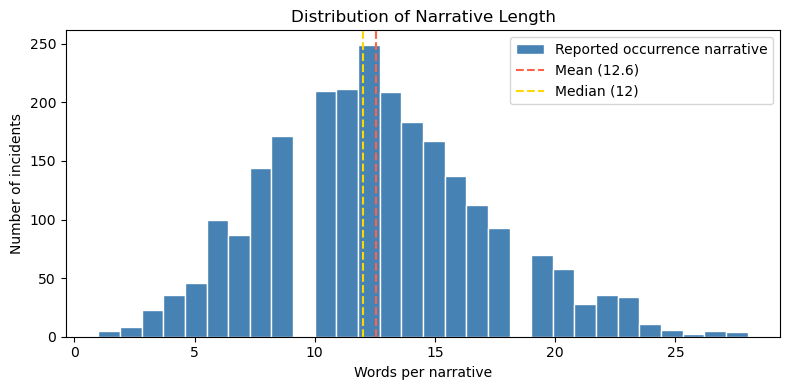

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
word_counts.plot.hist(bins=30, edgecolor='white', color='steelblue', ax=ax)
ax.axvline(word_counts.mean(), color='tomato', linestyle='--', linewidth=1.5, label=f'Mean ({word_counts.mean():.1f})')
ax.axvline(word_counts.median(), color='gold', linestyle='--', linewidth=1.5, label=f'Median ({word_counts.median():.0f})')
ax.set_xlabel('Words per narrative')
ax.set_ylabel('Number of incidents')
ax.set_title('Distribution of Narrative Length')
ax.legend()
plt.tight_layout()
plt.show()

## AND-102 Task 6 — Part 2: Text Cleaning with spaCy

Before analyzing the narratives, the text needs to be cleaned. Each narrative is lowercased, punctuation is removed, common words like "the" or "and" are dropped, and words are reduced to their base form so that "falling" and "fell" count as the same thing.

In [27]:
import spacy

nlp = spacy.load('en_core_web_sm')

def clean_narrative(text: str) -> str:
    doc = nlp(text.lower())
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop and not token.is_punct and not token.is_space
    ]
    return ' '.join(tokens)

narratives_clean = narratives.apply(clean_narrative)
print('Done. Sample cleaned narratives:')
for raw, cleaned in zip(narratives.head(5), narratives_clean.head(5)):
    print(f'  RAW    : {raw}')
    print(f'  CLEANED: {cleaned}')
    print()

Done. Sample cleaned narratives:
  RAW    : Elevator-Flood on 13th floor ran down the stairs and through the elevators
  CLEANED: elevator flood 13th floor run stair elevator

  RAW    : Elevator-Flood on 13th floor ran down stairs and into elevators no injuries
  CLEANED: elevator flood 13th floor run stair elevator injury

  RAW    : Elevator-Man with dog tried to kick dog leash into elevator and caught foot between doors and fell broke his arm.
  CLEANED: elevator man dog try kick dog leash elevator catch foot door fall break arm

  RAW    : Elevator - a piece of trim fell on person in elevator sore back
  CLEANED: elevator piece trim fall person elevator sore

  RAW    : Elevator-Elderly man exiting elevator got hit with door and fell backwards sustained cut to left eyebrow
  CLEANED: elevator elderly man exiting elevator get hit door fall backwards sustain cut leave eyebrow



In [28]:
df_clean = df.loc[narratives.index].copy()
df_clean['narrative_clean'] = narratives_clean.values

print(f'Rows with cleaned narrative: {len(df_clean):,}')
df_clean[['Incident Number', 'Reported occurrence narrative', 'narrative_clean']].head(5)

Rows with cleaned narrative: 2,445


,Incident Number,Reported occurrence narrative,narrative_clean
0,518574,Elevator-Flood on 13th floor ran down the stai...,elevator flood 13th floor run stair elevator
1,518582,Elevator-Flood on 13th floor ran down stairs a...,elevator flood 13th floor run stair elevator i...
2,519464,Elevator-Man with dog tried to kick dog leash ...,elevator man dog try kick dog leash elevator c...
3,524274,Elevator - a piece of trim fell on person in e...,elevator piece trim fall person elevator sore
4,519720,Elevator-Elderly man exiting elevator got hit ...,elevator elderly man exiting elevator get hit ...


## AND-102 Task 6 — Part 3: Approach Justification

Two options were considered: LDA topic modeling and TF-IDF with K-Means clustering. LDA works best with long documents because it needs enough words per text to find reliable patterns — at a median of 12 words per narrative, these reports are too short for it to work well. TF-IDF with K-Means was chosen instead because it handles short texts well, groups narratives by vocabulary similarity, and the output is easy to interpret: you get actual incident sentences per group rather than abstract word distributions.

## AND-102 Task 6 — Part 4: TF-IDF + K-Means Clustering

Each narrative is converted into a vector of numbers based on word frequency, then K-Means groups similar narratives together. The top words per group and the most representative incident descriptions are shown for each cluster.

### Choosing the Number of Clusters

K-Means needs you to tell it how many groups to create. To decide, the algorithm was run with K=2 through 11 and the result quality was measured at each step. The chart below shows that after K=5 the improvement starts flattening out, and the 5 groups produced are clear and easy to label. Going higher would split existing groups into variations that are too similar to be useful.

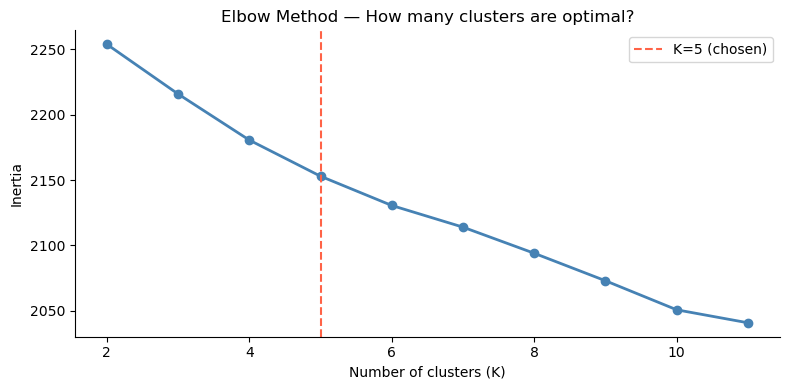

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

vectorizer_elbow = TfidfVectorizer(max_features=500)
X_elbow = vectorizer_elbow.fit_transform(narratives_clean)

inertias = []
K_range = range(2, 12)
for k in K_range:
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_k.fit(X_elbow)
    inertias.append(km_k.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_range), inertias, marker='o', color='steelblue', linewidth=2)
ax.axvline(5, color='tomato', linestyle='--', linewidth=1.5, label='K=5 (chosen)')
ax.set_xlabel('Number of clusters (K)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method — How many clusters are optimal?')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import numpy as np

N_CLUSTERS = 5

vectorizer = TfidfVectorizer(max_features=500)
X = vectorizer.fit_transform(narratives_clean)

km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
km.fit(X)

df_clean['cluster'] = km.labels_

print(f'Vectorizer vocabulary size: {len(vectorizer.vocabulary_):,}')
print(f'Matrix shape: {X.shape}')
print(f'Cluster sizes:')
print(df_clean['cluster'].value_counts().sort_index().to_string())

Vectorizer vocabulary size: 500
Matrix shape: (2445, 500)
Cluster sizes:
cluster
0    623
1    307
2    369
3    816
4    330


In [31]:
terms = vectorizer.get_feature_names_out()
order_centroids = km.cluster_centers_.argsort()[:, ::-1]

print('=== Top 10 terms per cluster ===\n')
for cluster_id in range(N_CLUSTERS):
    top_terms = [terms[i] for i in order_centroids[cluster_id, :10]]
    print(f'Cluster {cluster_id}: {", ".join(top_terms)}')

print('\n=== Representative narratives (3 closest to centroid) ===\n')
X_dense = X.toarray()
for cluster_id in range(N_CLUSTERS):
    mask = km.labels_ == cluster_id
    cluster_X = X_dense[mask]
    centroid = km.cluster_centers_[cluster_id]
    distances = np.linalg.norm(cluster_X - centroid, axis=1)
    closest_positions = np.argsort(distances)[:3]
    cluster_narratives = df_clean.loc[mask, 'Reported occurrence narrative'].values
    top_terms = [terms[i] for i in order_centroids[cluster_id, :5]]
    print(f'--- Cluster {cluster_id} | top terms: {", ".join(top_terms)} ---')
    for pos in closest_positions:
        print(f'  • {cluster_narratives[pos]}')
    print()

=== Top 10 terms per cluster ===

Cluster 0: door, elevator, close, hand, hit, arm, get, injury, open, female
Cluster 1: pit, water, flood, elevator, sump, pump, foot, damage, rope, failure
Cluster 2: water, elevator, hoistway, pipe, damage, flood, burst, go, floor, leak
Cluster 3: elevator, car, oil, fall, stop, find, drop, floor, break, rope
Cluster 4: trip, level, elevator, injury, fall, lady, female, knee, woman, report

=== Representative narratives (3 closest to centroid) ===

--- Cluster 0 | top terms: door, elevator, close, hand, hit ---
  • Elevator-Injury to mans arm door closed on it.
  • Elevator-Someone got hit by door put a complaint in they had not injury but thought it might be a risk to public
  • Elevator door closed on womens arm bruised

--- Cluster 1 | top terms: pit, water, flood, elevator, sump ---
  • Elevator-Water in pit
  • Elevator-water in pit will copy  client
  • Elevator-Water in pit

--- Cluster 2 | top terms: water, elevator, hoistway, pipe, damage ---

In [32]:
CLUSTER_LABELS = {
    0: 'Door-related injuries',
    1: 'Water / flooding in pit',
    2: 'Pipe burst / hoistway flooding',
    3: 'Mechanical failures (oil, rope, car drop)',
    4: 'Leveling issues / trip-and-fall',
}

df_clean['cluster_label'] = df_clean['cluster'].map(CLUSTER_LABELS)

print('=== Cluster summary ===\n')
summary = (
    df_clean.groupby(['cluster', 'cluster_label'])
    .size()
    .reset_index(name='count')
    .sort_values('cluster')
)
for _, row in summary.iterrows():
    pct = row['count'] / len(df_clean) * 100
    print(f"  Cluster {row['cluster']} — {row['cluster_label']}: {row['count']:,} incidents ({pct:.1f}%)")

=== Cluster summary ===

  Cluster 0 — Door-related injuries: 623 incidents (25.5%)
  Cluster 1 — Water / flooding in pit: 307 incidents (12.6%)
  Cluster 2 — Pipe burst / hoistway flooding: 369 incidents (15.1%)
  Cluster 3 — Mechanical failures (oil, rope, car drop): 816 incidents (33.4%)
  Cluster 4 — Leveling issues / trip-and-fall: 330 incidents (13.5%)


## AND-102 Task 6 — Part 5: Visualizations

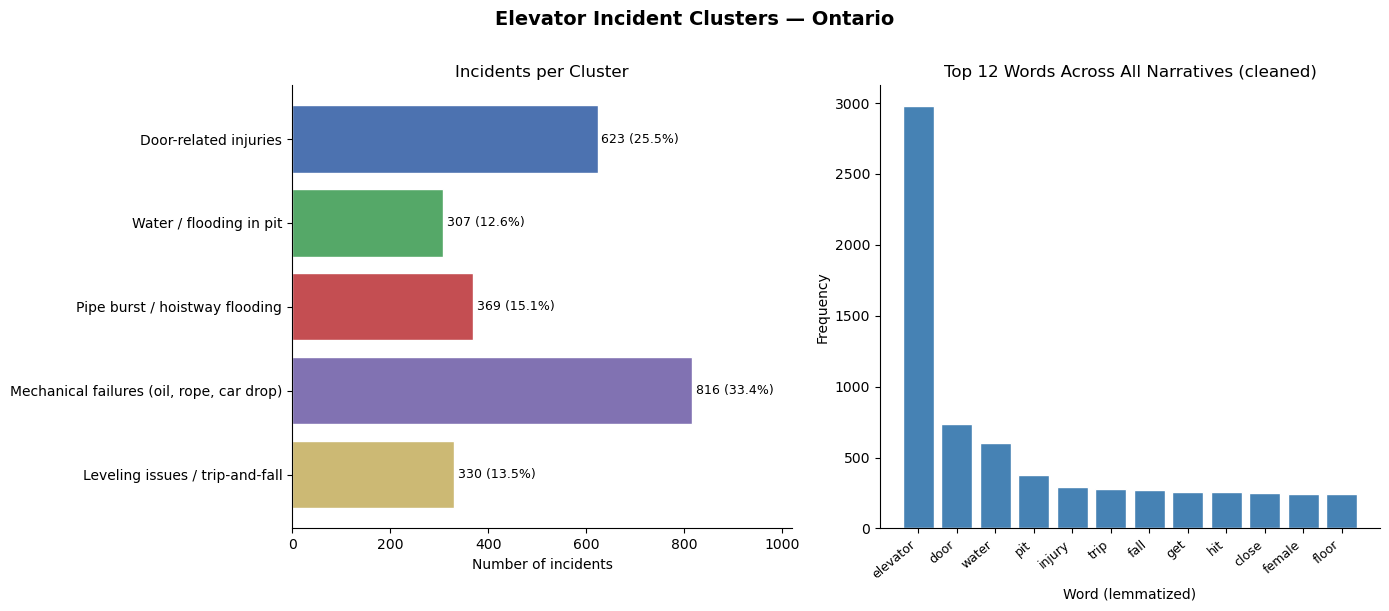

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

COLORS = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']

cluster_counts = df_clean['cluster_label'].value_counts().reindex(CLUSTER_LABELS.values())
labels = cluster_counts.index.tolist()
sizes = cluster_counts.values

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Elevator Incident Clusters — Ontario', fontsize=14, fontweight='bold', y=1.01)

# --- Chart 1: Horizontal bar chart (cluster sizes) ---
ax = axes[0]
bars = ax.barh(labels, sizes, color=COLORS, edgecolor='white')
ax.set_xlabel('Number of incidents')
ax.set_title('Incidents per Cluster')
ax.invert_yaxis()
for bar, count in zip(bars, sizes):
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height() / 2,
            f'{count} ({count/len(df_clean)*100:.1f}%)',
            va='center', fontsize=9)
ax.set_xlim(0, sizes.max() * 1.25)
ax.spines[['top', 'right']].set_visible(False)

# --- Chart 2: Top 8 words across all narratives ---
from collections import Counter
all_words = ' '.join(narratives_clean).split()
word_freq = Counter(all_words).most_common(12)
words, freqs = zip(*word_freq)

ax2 = axes[1]
ax2.bar(words, freqs, color='steelblue', edgecolor='white')
ax2.set_title('Top 12 Words Across All Narratives (cleaned)')
ax2.set_ylabel('Frequency')
ax2.set_xlabel('Word (lemmatized)')
plt.setp(ax2.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## AND-102 Task 6 — Part 6: Summary

The analysis of 2,445 Ontario elevator incident narratives found five clear patterns. Mechanical failures — oil leaks, rope issues, car drops — are the most common at 33.4% of all incidents and carry the highest risk. Door-related injuries come second at 25.5%, mostly doors closing on passengers' hands and arms, a problem that tends to be preventable. Water intrusion shows up across two separate clusters: pipe bursts that flood the hoistway (15.1%) and water accumulating in the pit (12.6%), together making up over a quarter of all reports and pointing to building infrastructure as a recurring source of elevator problems. Leveling issues where the car stops slightly above or below the floor account for 13.5% of incidents and regularly cause passengers to trip, particularly elderly riders. The operations team should focus preventive maintenance on door mechanisms and mechanical components, and flag buildings with repeated water incidents for follow-up with property management.